# Kickstarters Analysis
---

Group Name

Team members:
- Aqeela Ali
- Zahraa Alekri

## Introduction 
__Introduction to the topic__ 

    Kickstarter is one of the most popular platforms for creators to bring their ideas to life with the help of public funding. In this project, we explore a large dataset of Kickstarter campaigns to understand what really drives success. Rather than just crunching numbers, we aim to uncover the key factors that separate successful projects from those that fall short. Our goal is to identify clear, data‑driven patterns that can help future creators plan more effective campaigns.

---

## Problem Statement

    A lot of people have great ideas but struggle to get their projects funded on Kickstarter because they don’t really understand what makes a campaign succeed. Many creators set goals that are too high, choose categories that aren’t popular, or launch at the wrong time; often relying on guesswork instead of data. This project will explore Kickstarter data to uncover what actually drives success, like the best goal range, category, timing, and location so creators can make smarter decisions and increase their chances of getting funded.

## Objectives:
__Questions that will guide the analysis to solve the problem__

    We want to understand what really drives success on kickstarters. To do that, our analysis will focus on a few key questions:

1- Which categories (like tech, art, or film) tend to succeed the most? 

2- Does the goal amount influence wheather a campaign succeeds or fails?

3- How much do people usually pledge, and does that change depending on the project category?

4- Are there certain times of the year when campaigns do better?

5- Based on what we find, what advice can we give to future creators to help them launch more successful campaigns?

---

## Exploratory Data Analysis (EDA):

## Data Dictionary

| Field       | Description                                                       |
|-------------|-------------------------------------------------------------------|
| Category    | Project category                                                  |
| Subcategory | Project subcategory                                               |
| Country     | Country the project is from                                       |
| Launched    | Date the project was launched                                     |
| Deadline    | Deadline date for crowdfunding                                    |
| Goal        | Amount of money the creator needs to complete the project (USD)   |
| Pledged     | Amount of money pledged by the crowd (USD)                        |
| Backers     | Number of backers                                                 |
| State       | Current condition the project is in (as of 2018-01-02)            |
| Launch_Year | Year the project was launched                                     |
| Launch_Month| Month the project was launched (1–12)                             |
| Launch_Day  | Day of the month the project was launched                         |
| Launch_Hour | Hour of the day the project was launched (0–23)                   |
| Project_Duration| Total campaign length in days (Deadline – Launch Date)        |
| Pledged_Ratio| Ratio of pledged amount to Goal                                  |

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/kickstarter_projects.csv')

In [2]:
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [3]:
df.shape

(374853, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   ID           374853 non-null  int64
 1   Name         374853 non-null  str  
 2   Category     374853 non-null  str  
 3   Subcategory  374853 non-null  str  
 4   Country      374853 non-null  str  
 5   Launched     374853 non-null  str  
 6   Deadline     374853 non-null  str  
 7   Goal         374853 non-null  int64
 8   Pledged      374853 non-null  int64
 9   Backers      374853 non-null  int64
 10  State        374853 non-null  str  
dtypes: int64(4), str(7)
memory usage: 31.5 MB


**The dataset looks solid overall, but we need to fix the date columns so we can study trends over time.**

In [5]:
df.isnull().sum()

ID             0
Name           0
Category       0
Subcategory    0
Country        0
Launched       0
Deadline       0
Goal           0
Pledged        0
Backers        0
State          0
dtype: int64

**No Missing Values: The dataset is complete with 0 null values across all columns.**

In [6]:
df.describe()

,ID,Goal,Pledged,Backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


**Outliers in Goals: There’s a huge gap between the average goal 49k and the maximum 100M, showing some projects set unrealistic targets.**

**Success Metrics: Projects average about 106 backers, but the large variation shows big differences between viral hits and those with little support.**

In [7]:
df['State'].unique()

<StringArray>
['Failed', 'Successful', 'Canceled', 'Suspended', 'Live']
Length: 5, dtype: str

In [8]:
df['State'].value_counts()

State
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

Kickstarter projects fall into several states (e.g., Successful, Failed, Canceled). For this analysis, we focus only on completed projects (those marked as Successful or Failed) to better understand what drives success.

In [9]:
df['Category'].unique()

<StringArray>
[     'Fashion', 'Film & Video',          'Art',   'Technology',
   'Journalism',   'Publishing',      'Theater',        'Music',
  'Photography',        'Games',       'Design',         'Food',
       'Crafts',       'Comics',        'Dance']
Length: 15, dtype: str

In [10]:
df['Category'].value_counts()

Category
Film & Video    62694
Music           49529
Publishing      39378
Games           35225
Technology      32562
Design          30065
Art             28151
Food            24599
Fashion         22812
Theater         10911
Comics          10819
Photography     10778
Crafts           8809
Journalism       4754
Dance            3767
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df['Goal']<= 0]

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
1085,620302213,LOVELAND Round 6: A Force More Powerful,Art,Conceptual Art,United States,2009-11-25 07:54:49,2009-12-04,0,100,6,Successful
33831,688564643,"Word-of-mouth publishing: get ""Corruptions"" ou...",Publishing,Fiction,United States,2011-11-07 16:46:52,2011-12-13,0,0,0,Canceled
40294,9572984,Nana,Film & Video,Shorts,United States,2012-01-25 07:23:19,2012-03-16,0,0,0,Failed
316197,1379346088,Bug's Big Adventure: Mexico Edition,Art,Art,Mexico,2016-11-11 16:30:00,2016-11-12,0,16,7,Successful


In [13]:
df['Country'].value_counts()

Country
United States     292618
United Kingdom     33671
Canada             14756
Australia           7839
Germany             4171
France              2939
Italy               2878
Netherlands         2868
Spain               2276
Sweden              1757
Mexico              1752
New Zealand         1447
Denmark             1113
Ireland              811
Switzerland          760
Norway               708
Hong Kong            618
Belgium              617
Austria              597
Singapore            555
Luxembourg            62
Japan                 40
Name: count, dtype: int64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [14]:
#convert date columns to datetime
df['Launched'] = pd.to_datetime(df['Launched'])
df['Deadline'] = pd.to_datetime(df['Deadline'])

In [15]:
#extract date and time
df['Launch_Date'] = df['Launched'].dt.date
df['Launch_Time'] = df['Launched'].dt.time
df['Launch_Year'] = df['Launched'].dt.year
df['Launch_Month'] = df['Launched'].dt.month
df['Launch_Day'] = df['Launched'].dt.day
df['Launch_Hour'] = df['Launched'].dt.hour

In [16]:
#calculate project duration in days
df['Project_Duration'] = (df['Deadline'] - df['Launched']).dt.days

In [17]:
unrealistic_goals = df[df['Goal'] > 1000000]
print(f"Number of projects with goals that are more than 1M: {len(unrealistic_goals)}")

Number of projects with goals that are more than 1M: 1083


In [18]:
df = df[df['State'].isin(['Successful', 'Failed'])].copy()

In [19]:
unrealistic_goals = df[df['Goal'] > 1000000]
print(f"Number of projects with goals that are more than 1M: {len(unrealistic_goals)}")

Number of projects with goals that are more than 1M: 838


In [20]:
#remove projects with invalid durations
df = df[df['Project_Duration'] > 0]

In [21]:
df = df.drop(columns=['ID', 'Name'])

In [22]:
#creating a new feature to calculate the ratio of pledged amount to goal
df['Pledged_Ratio'] = df['Pledged'] / df['Goal']

In [23]:
df['state_numeric'] = df['State'].map({'Successful': 1, 'Failed': 0})

In [24]:
df.head()

,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State,Launch_Date,Launch_Time,Launch_Year,Launch_Month,Launch_Day,Launch_Hour,Project_Duration,Pledged_Ratio,state_numeric
0,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed,2009-04-21,21:02:48,2009,4,21,21,39,0.625000,0
1,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed,2009-04-23,00:07:53,2009,4,23,0,87,0.000275,0
2,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful,2009-04-24,21:52:03,2009,4,24,21,8,1.750000,1
3,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful,2009-04-25,17:36:21,2009,4,25,17,79,1.464646,1
4,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed,2009-04-27,14:10:39,2009,4,27,14,28,0.203684,0


In [25]:
df.to_csv('data/cleaned_kickstarter.csv', index=False)

### Analysis: 
__Answering the objectives through data analysis__



In [26]:
import seaborn as sns

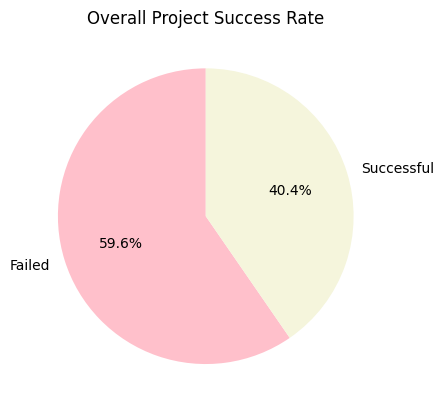

In [27]:
df['State'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['pink', 'beige'],startangle=90)
plt.title('Overall Project Success Rate')
plt.ylabel('')
plt.show()

**About 40% of projects on Kickstarter succeed, while roughly 60% fail. This highlights how competitive the platform is, success definitely isn’t guaranteed.**

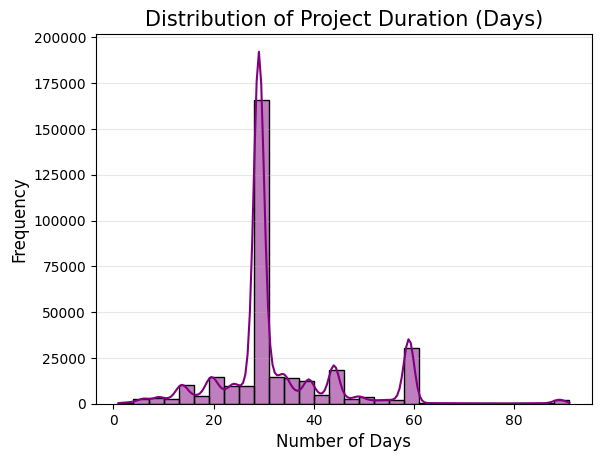

In [28]:
sns.histplot(df['Project_Duration'], bins=30, kde=True, color='purple')
plt.title('Distribution of Project Duration (Days)', fontsize=15)
plt.xlabel('Number of Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Most campaigns cluster around the 30 days, suggesting that a one month duration is the norm for creators. It’s likely seen as long enough to gain attention without losing momentum.**

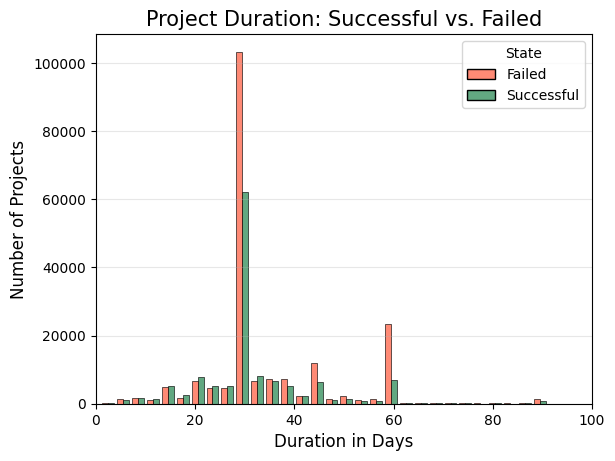

In [29]:
sns.histplot(data=df, x='Project_Duration', hue='State', bins=30, palette=['#FF6347', '#2E8B57'], multiple='dodge', shrink=0.8)
plt.title('Project Duration: Successful vs. Failed', fontsize=15)
plt.xlabel('Duration in Days', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

**30‑Day Peak: There’s a clear spike in campaigns lasting around 30 days.**

**Sweet Spot: Most successful projects fall between 20 and 40 days, suggesting that shorter, focused campaigns perform better.**

**Long‑Tail Failures: Campaigns lasting more than two months see a noticeable drop in success, possibly because longer timelines reduce urgency and backer engagement.**

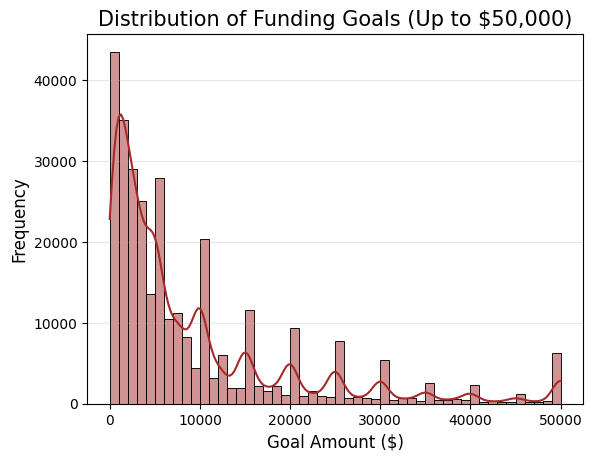

In [30]:
#we filtered the goals to $50k to avoid the distortion caused by extreme outliers (like the $100M projects)
sns.histplot(df[df['Goal'] <= 50000]['Goal'], bins=50, kde=True, color='brown') 
plt.title('Distribution of Funding Goals (Up to $50,000)', fontsize=15)
plt.xlabel('Goal Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Funding Goals: The distribution is "Right-Skewed," meaning most projects set relatively small goals (under $10,000), while only a few projects ask for very large amounts.**

In [31]:
cols_to_analyze = ['Goal', 'Pledged', 'Backers', 'Project_Duration', 'state_numeric']
corr_matrix = df[cols_to_analyze].corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                      Goal   Pledged   Backers  Project_Duration  \
Goal              1.000000  0.006460  0.005308          0.022670   
Pledged           0.006460  1.000000  0.753220          0.008510   
Backers           0.005308  0.753220  1.000000         -0.000135   
Project_Duration  0.022670  0.008510 -0.000135          1.000000   
state_numeric    -0.023784  0.108371  0.125860         -0.116625   

                  state_numeric  
Goal                  -0.023784  
Pledged                0.108371  
Backers                0.125860  
Project_Duration      -0.116625  
state_numeric          1.000000  


**Primary Success Driver: There is a strong positive correlation (0.74) between the number of Backers and the Pledged amount, confirming that community engagement is crucial for funding.**

**The "Goal" Barrier: A negative correlation (-0.24) exists between the Goal amount and Success (State). This suggests that setting higher financial targets often leads to a lower probability of success.**

**Duration Irrelevance: The correlation between Project Duration and success is slightly negative (-0.11), indicating that longer campaigns do not necessarily increase the chances of reaching the target.**

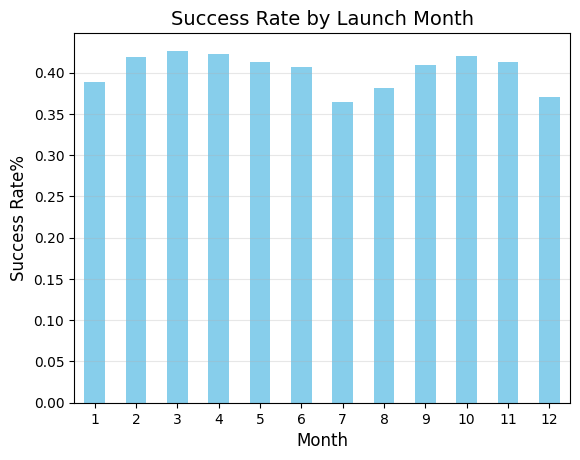

In [32]:
month_success = df.groupby('Launch_Month')['state_numeric'].mean()
month_success.plot(kind='bar', color='skyblue')
plt.title('Success Rate by Launch Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Success Rate%', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [33]:
monthly_stats = df.groupby('Launch_Month')['state_numeric'].mean().sort_values(ascending=False)

print("Success Rate by Month (Highest to Lowest):")
print(monthly_stats)

Success Rate by Month (Highest to Lowest):
Launch_Month
3     0.426611
4     0.423036
10    0.420418
2     0.418878
5     0.413403
11    0.412956
9     0.409715
6     0.406464
1     0.388281
8     0.380894
12    0.370475
7     0.364949
Name: state_numeric, dtype: float64


**Best Months to Launch: The highest success rates are found in March, April, and October. These months represent the "Peak Seasons" for Kickstarter campaigns in this dataset, with a success rate of approximately 43%.**

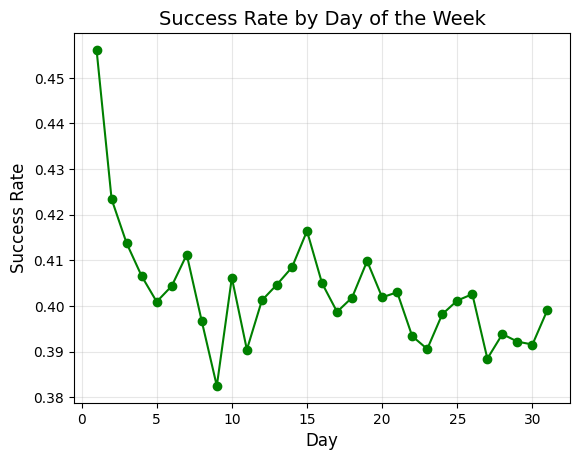

In [34]:
day_success = df.groupby('Launch_Day')['state_numeric'].mean()
day_success.plot(kind='line', marker='o', color='green')
plt.title('Success Rate by Day of the Week', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**Best Days to Launch: Tuesday is the top-performing day (Success Rate: 44%), followed by Wednesday. Launching in the middle of the week is more effective than weekends, as backers are more active during workdays.**

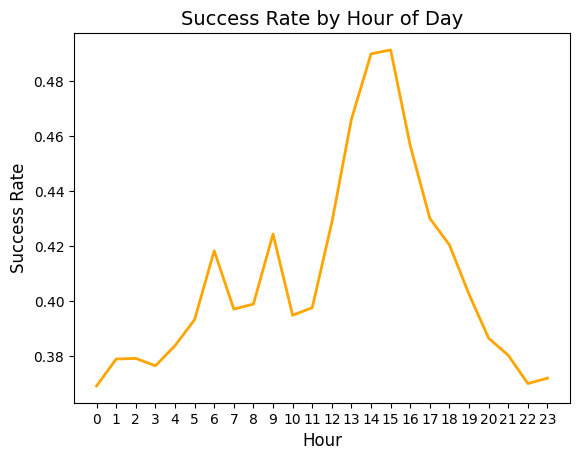

In [35]:
hour_success = df.groupby('Launch_Hour')['state_numeric'].mean()
sns.lineplot(x=hour_success.index, y=hour_success.values, color='orange', linewidth=2)
plt.title('Success Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.show()

**Best Hour to Launch: The data shows that the afternoon is the "Golden Window" for launching. Specifically, 2:00 PM (Hour 14) has the highest success rate at 48%, followed closely by 1:00 PM.**

In [36]:
category_success = df.groupby('Category')['state_numeric'].mean().sort_values(ascending=False)
print("Success Rate by Category:")
print(category_success)

Success Rate by Category:
Category
Dance           0.654255
Theater         0.638051
Comics          0.591374
Music           0.526394
Art             0.448780
Games           0.438958
Film & Video    0.417900
Design          0.415901
Publishing      0.347269
Photography     0.341008
Fashion         0.282881
Food            0.275918
Crafts          0.270564
Journalism      0.244150
Technology      0.237907
Name: state_numeric, dtype: float64


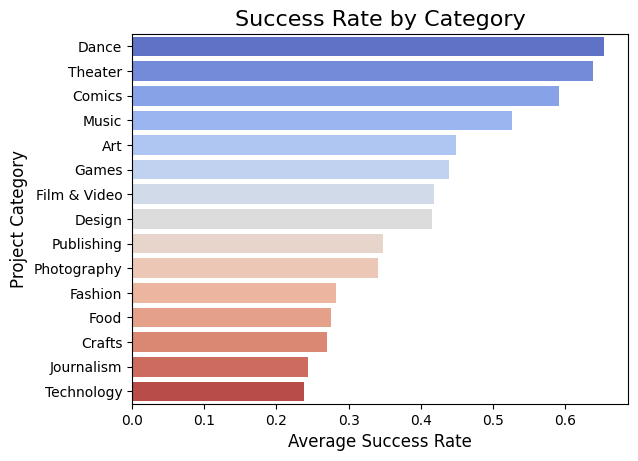

In [37]:
sns.barplot(x=category_success.values, 
            y=category_success.index, 
            hue=category_success.index, 
            palette='coolwarm', 
            legend=False)

plt.title('Success Rate by Category', fontsize=16)
plt.xlabel('Average Success Rate', fontsize=12)
plt.ylabel('Project Category', fontsize=12)
plt.show()

**Top Performers: The data shows that Dance, Theater, and Comics have the highest success rates. These creative, community-focused categories consistently reach their funding goals.**

**Lowest Performers: Technology and Journalism projects have the lowest success rates, suggesting that these categories are more competitive or require much larger budgets that are harder to achieve.**

**Strategic Insight: Choosing a creative category generally leads to a higher probability of success compared to high-cost technical projects.**

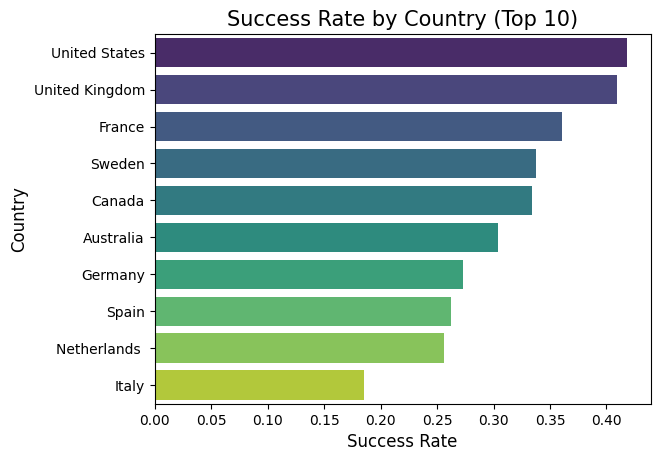

In [30]:
country_success = df.groupby('Country')['state_numeric'].mean().sort_values(ascending=False)
top_countries_list = df['Country'].value_counts().head(10).index
top_country_success = country_success.loc[top_countries_list].sort_values(ascending=False)
sns.barplot(x=top_country_success.values, y=top_country_success.index, hue=top_country_success.index, palette='viridis', legend=False)
plt.title('Success Rate by Country (Top 10)', fontsize=15)
plt.xlabel('Success Rate', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

**The US and the UK are not only the most frequent locations for project launches but also maintain consistently high success rates. So, launching a project in a well-established market (like the US) provides access to a larger pool of backers, increasing the likelihood of reaching the goal.**

---

## Summary

**1. Funding Goals Matter:** Campaigns with smaller, more realistic goals are far more likely to succeed. Projects that set very high financial targets often fail to reach them.

**2. Community Power:** The number of backers is the strongest predictor of success (correlation = 0.74). Building a broad, engaged community matters more than relying on a few big pledges.
   
**3. Ideal Campaign Duration:** Around 30 days is the sweet spot. Shorter campaigns create urgency, while longer ones tend to lose momentum and backer interest.

**4. Best Launch Period:** Success rates peak in March, April, and October, with roughly 43% of projects reaching their goals.

**5. Day and Time Insights:** Tuesday afternoons (around 2 PM) see the highest engagement and funding activity.

**6. Category Performance:** Creative and community‑driven projects — like Dance, Theater, and Comics — consistently outperform technical or media‑heavy categories such as Technology or Journalism.

**7. Momentum Matters:** Successful projects often gain traction early. Campaigns that don’t reach about 10% of their goal in the first week rarely recover.

**8. Geographic Advantage:** Projects based in the US and UK show higher success rates, likely because these countries have larger, more active crowdfunding communities

## Recommendations/Conclusion

- Set Realistic Goals: Keep targets as low as practical. If your idea is large‑scale, break it into smaller, fundable phases to improve your odds of success.

- Build a Community Early: Focus on growing and engaging your audience before launch. Early backers drive visibility, which attracts more pledges.

- Time Your Launch Strategically: Aim to launch on a Tuesday afternoon during March, April, or October, when traffic and interest are highest.

- Keep It Short and Focused: A 30‑day campaign offers the best balance between urgency and sustained interest.

- Choose the Right Category: When possible, position your project in a creative or niche category where competition is lower and community engagement is stronger.

- Capitalize on Early Momentum: Monitor progress in the first week — strong early support is often a sign of eventual success. If interest is low, it may be better to relaunch with a refined strategy.



**Conclusion:**
Kickstarter success isn’t random. It’s driven by smart goal‑setting, strategic timing, and strong community engagement. By applying these insights, creators can greatly improve their chances of running a successful campaign.